In [4]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv('../data/raw/voyage_p3.csv')

In [ ]:
# df_sim = df[df['job_id'].isin(range(136, 142))]
# Total Job-Level Tardiness : 68.0 Jam
# Total Congestion Wait     : 10.0 Jam
# Total Tidal Wait          : 18.0 Jam
# Total Defisit Waktu (Negative Slack): 32.0 Jam

df_sim = df[df['job_id'].isin(range(315, 321))]
# Total Job-Level Tardiness : 73.0 Jam
# Total Congestion Wait     : 12.0 Jam
# Total Tidal Wait          : 10.0 Jam
# Total Defisit Waktu (Negative Slack): 24.0 Jam

# target kapal DOBONSOLO
mask_kapal = df_sim['ship_name'] == 'KM.DOBONSOLO'

# cek apakah dalam satu job ada port tertentu
has_special_port = (
    df_sim[mask_kapal]
    .groupby('job_id')['port_name']
    .transform(lambda x: x.isin(['BIAK', 'JAYAPURA']).any())
)

# assign rute
df_sim.loc[mask_kapal, 'rute'] = has_special_port.map({True: 'A', False: 'B'})


# target kapal KELIMUTU
mask_kapal = df_sim['ship_name'] == 'KM.KELIMUTU'

# cek apakah dalam satu job ada port tertentu
has_special_port = (
    df_sim[mask_kapal]
    .groupby('job_id')['port_name']
    .transform(lambda x: x.isin(['BATULICIN', 'SURABAYA']).any())
)

# assign rute
df_sim.loc[mask_kapal, 'rute'] = has_special_port.map({True: 'B', False: 'A'})

# target kapal DOROLONDA
mask_kapal = df_sim['ship_name'] == 'KM.DOROLONDA'

# cek apakah dalam satu job ada port tertentu
has_special_port = (
    df_sim[mask_kapal]
    .groupby('job_id')['port_name']
    .transform(lambda x: x.isin(['WAREN', 'NAMLEA']).any())
)

# assign rute
df_sim.loc[mask_kapal, 'rute'] = has_special_port.map({True: 'B', False: 'A'})

# target kapal LAWIT
mask_kapal = df_sim['ship_name'] == 'KM.LAWIT'

# cek apakah dalam satu job ada port tertentu
has_special_port = (
    df_sim[mask_kapal]
    .groupby('job_id')['port_name']
    .transform(lambda x: x.isin(['BENOA', 'BIMA', 'WAINGAPU', 'ENDE', 'KALABAHI', 'KUPANG', 'ROTE']).any())
)

# assign rute
df_sim.loc[mask_kapal, 'rute'] = has_special_port.map({True: 'B', False: 'A'})

# target kapal BINAIYA
mask_kapal = df_sim['ship_name'] == 'KM.BINAIYA'

# cek apakah dalam satu job ada port tertentu
has_special_port = (
    df_sim[mask_kapal]
    .groupby('job_id')['port_name']
    .transform(lambda x: x.isin(['WAINGAPU', 'ENDE', 'KUPANG']).any())
)

# assign rute
df_sim.loc[mask_kapal, 'rute'] = has_special_port.map({True: 'B', False: 'A'})

# target kapal TATAMAILAU
mask_kapal = df_sim['ship_name'] == 'KM.TATAMAILAU'

# cek apakah dalam satu job ada port tertentu
has_special_port = (
    df_sim[mask_kapal]
    .groupby('job_id')['port_name']
    .transform(lambda x: x.isin(['TERNATE', 'AMBON']).any())
)

# assign rute
df_sim.loc[mask_kapal, 'rute'] = has_special_port.map({True: 'B', False: 'A'})

# Drop column due_date
# df_sim = df_sim.drop(columns=['due_date'])

# Simpan
df_sim.to_csv('../data/processed/voyage_sim.csv', index=False)

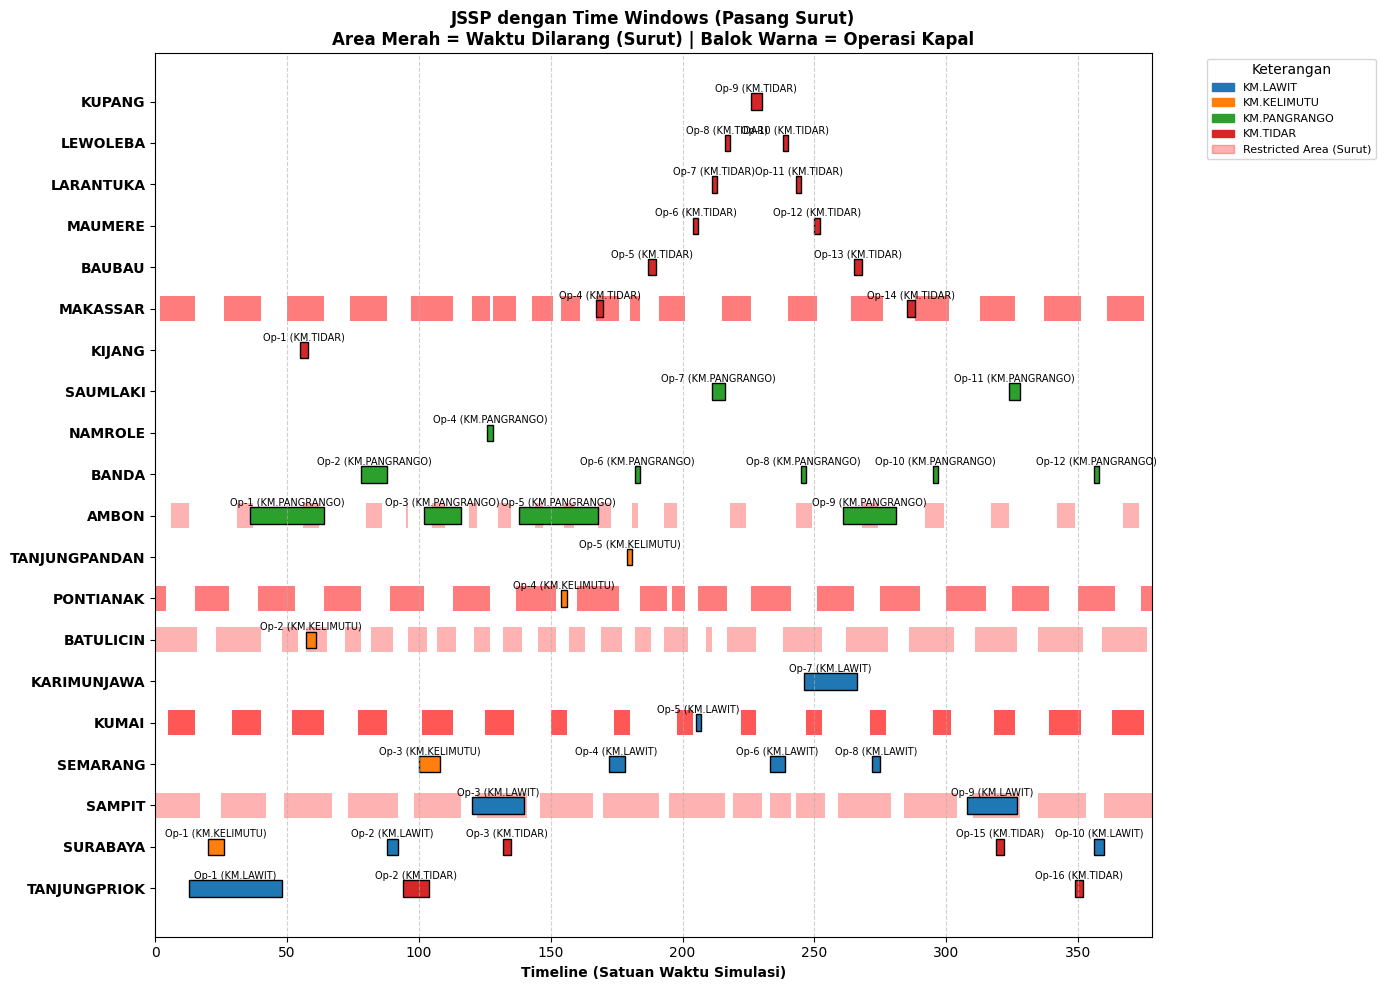

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import io

# --- 1. Load Data ---
voyage_path = '../data/processed/voyage_sim.csv'
tide_path = '../data/processed/tidal_lookup_0000.csv'

df_voyage = pd.read_csv(voyage_path)
df_tide = pd.read_csv(tide_path)

# --- 1.5. Optimasi Filter Batas Waktu (Windowing) ---
# Mencari titik waktu paling akhir dari seluruh operasi di batch ini
# Karena due_date bisa saja memiliki buffer, kita gunakan arrival_time + proc_time sebagai titik penyelesaian logis terluar
max_time_in_batch = (df_voyage['arrival_time'] + df_voyage['proc_time']).max()

# Tambahkan buffer visual (misal 5% dari total waktu atau nilai absolut) agar balok terakhir tidak menabrak tepi grafik
visual_buffer = max_time_in_batch * 0.05
plot_limit = max_time_in_batch + visual_buffer

# FILTERING KRUSIAL: Potong data pasang surut sebelum di-looping
# Ini akan menghemat resource komputasi secara drastis
df_tide_filtered = df_tide[df_tide['t'] <= plot_limit]

# ---------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 10))

# Mapping Sumbu Y = Pelabuhan (Mesin)
ports = df_voyage['port_name'].unique()
port_y = {port: i for i, port in enumerate(ports)}

# Mapping Warna = Kapal (Job)
ships = df_voyage['ship_name'].unique()
colors = plt.cm.tab10.colors 
ship_color = {ship: colors[i % len(colors)] for i, ship in enumerate(ships)}

# --- 2. Plotting Hard Constraints (Zona Surut / Tidak Aman) ---
for idx, row in df_tide_filtered.iterrows(): # Gunakan dataframe yang SUDAH DIFILTER
    if not row['is_allowed']:
        port = row['port_name']
        
        if port in port_y: 
            y_pos = port_y[port]
            t_start = row['t']
            
            ax.barh(y_pos, width=1.0, left=t_start, height=0.6, 
                    color='red', alpha=0.3, edgecolor='none')

# --- 3. Plotting Jadwal Operasi Kapal ---
for idx, row in df_voyage.iterrows():
    port = row['port_name']
    ship = row['ship_name']
    arrival = row['arrival_time']
    proc = row['proc_time']
    op_seq = row['op_seq']
    
    if port in port_y:
        y_pos = port_y[port]
        
        ax.barh(y_pos, proc, left=arrival, height=0.4, color=ship_color[ship], edgecolor='black')
        
        label_text = f"Op-{op_seq} ({ship})"
        ax.text(arrival + (proc / 2), y_pos + 0.3, label_text, va='center', ha='center', 
                color='black', fontsize=7, rotation=0)

# --- 4. Membatasi Sumbu X Secara Eksplisit ---
ax.set_xlim(0, plot_limit)

# Kustomisasi Sumbu Y
ax.set_yticks([port_y[p] for p in ports])
ax.set_yticklabels(ports, fontweight='bold')

# Dekorasi Grafik
ax.set_xlabel('Timeline (Satuan Waktu Simulasi)', fontweight='bold')
ax.set_title('JSSP dengan Time Windows (Pasang Surut)\nArea Merah = Waktu Dilarang (Surut) | Balok Warna = Operasi Kapal', fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.6)

# Membuat Legend
patches = [mpatches.Patch(color=ship_color[ship], label=ship) for ship in ships]
patches.append(mpatches.Patch(color='red', alpha=0.3, label='Restricted Area (Surut)'))

ax.legend(handles=patches, title="Keterangan", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()